In [1]:
from ESN import Reservoir
from narma import NARMA
from Qreservoir_fast import QReservoir
from tools import gen_input_states, gen_config_filepath, gen_system_filepath, gen_result_filepath, write_to_row, finish_row, unpack_config, folder_name

import numpy as np
import matplotlib.pyplot as plt
import os

#Pyörittelyt --------------------------------------------------------

In [2]:
classic = Reservoir(128)
classic.add_performance_task(NARMA(degree_=6))
classic.generate_inputs([1000,3000,5000])
classic.evolve_reservoir('task1', 'full')
classic.results['task1']

Added performance task 'NARMA(6, 0.3, 0.05, 0.375, 0)' as 'task1'


('NARMA(6, 0.3, 0.05, 0.375, 0)', np.float64(0.010377221203816078))

In [ ]:
for i in range(50):
    jeps = Reservoir(128, 0.9, 0.1)
    jeps.add_performance_task(NARMA(degree_=6))
    jeps.generate_inputs([1000,5000,3000])
    jeps.evolve_reservoir('task1', 'full')
    print(jeps.results['task1'])

In [2]:
gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding, n_models, n_train_inputs, n_test_inputs = unpack_config("Qreservoir_configurations/config1.json")

QReservoir_models = [QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding) for _ in range(n_models)]
train_inputs = np.array([gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

for Qreservoir in QReservoir_models:
    Qreservoir.init_reservoir("vacuum")
    Qreservoir.rk4_timesteps(4)

In [12]:
QReservoir_models[5] = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
QReservoir_models[7] = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
train_inputs[5] = gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding)
train_inputs[7] = gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding)


QReservoir_models[5].init_reservoir("vacuum")
QReservoir_models[5].rk4_timesteps(4)

QReservoir_models[7].init_reservoir("vacuum")
QReservoir_models[7].rk4_timesteps(4)

In [13]:
QReservoir_models[5].train_reservoir(train_inputs[5])
systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), 5)
QReservoir_models[5].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.9999999999839999+0j)
0
tr_res: (1+0j)
tr_new: (0.9999999735270001+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999955055+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999999135419999+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.999999862393+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999914897+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.9999999270490001+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.999999901065+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000071879+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000052804+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999965973+0j)
tr_res: (1+0j)
tr_new: (0.9999999203440002+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999989949+0j)
tr_res: (1+0j)
tr_new: (1.000000006199+0j)
tr_res: (1+0j)
tr_new: (1.0000000078709999+0j)
tr_res: (1+0j)
tr_new: (1.000000123104+0j)
tr_res: (1.0000003576278687+0j)
tr_new: (1.000000281204+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000267669+0

In [14]:
QReservoir_models[7].train_reservoir(train_inputs[7])
systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), 7)
QReservoir_models[7].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.9999999999879999+0j)
0
tr_res: (1+0j)
tr_new: (1.000000036851+0j)
tr_res: (1+0j)
tr_new: (1.000000025971+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.0000000694350002+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000106807+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.0000001868639998+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.0000001583990001+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000268797+0j)
tr_res: (1.0000003576278687+0j)
tr_new: (1.000000342864+0j)
tr_res: (1.0000003576278687+0j)
tr_new: (1.000000398186+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000249554+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000153822+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000069955+0j)
tr_res: (1+0j)
tr_new: (1.000000012719+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.0000000938299998+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000070682+0j)
tr_res: (1+0j)
tr_new: (1.0000000243590002+0j)
tr_res: (1+0j)
tr_new: (1.0000000953069998+

In [3]:
test_inputs_sq_th = np.array([gen_input_states("sq_th", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_add = np.array([gen_input_states("pho_add", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_sub = np.array([gen_input_states("pho_sub", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_simple = np.array([gen_input_states("simple", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].train_reservoir(train_inputs[i])
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    QReservoir_models[i].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.9999999999879999+0j)
0
tr_res: (1+0j)
tr_new: (1.000000029011+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999952832+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999854703+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997698969999+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.9999997129350001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997560230001+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.9999999046249999+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.9999998357519999+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.9999998623509999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998670349999+0j)
tr_res: (1+0j)
tr_new: (0.9999999648569999+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999954789+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000070109+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000035707+0j)
tr_res: (1+0j)
tr_new: (1.0000000057279999+0j)
tr_res: (1+0j)
tr_new: (0.9999999887790001+0j)
tr_res: (1+0j)
tr_n

In [ ]:
for i in range(n_models):
    QReservoir_models[i].test_reservoir(test_inputs_sq_th[i])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].test_reservoir(test_inputs_sq_pho_add[i])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].test_reservoir(test_inputs_sq_pho_sub[i])

In [ ]:
for i in range(n_models):
    QReservoir_models[i].test_reservoir(test_inputs_simple[i])

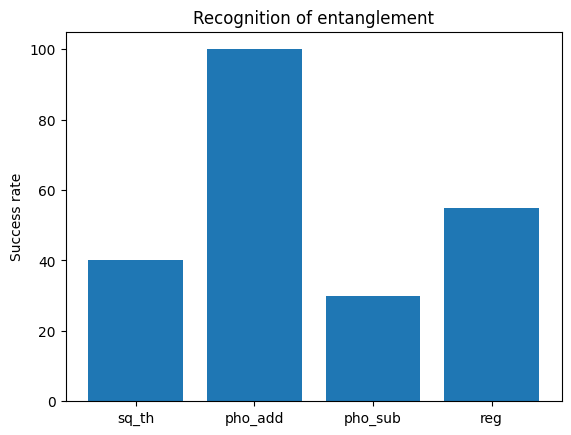

In [ ]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [7]:
train_in = gen_input_states("sq_th", 20, fock_truncation, sim_rounding)

test_pho_add = gen_input_states("pho_add", 20, fock_truncation)
test_pho_sub = gen_input_states("pho_sub", 20, fock_truncation)
test_simple = gen_input_states("simple", 20, fock_truncation)

In [8]:
Qres1 = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
Qres2 = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
Qres1.init_reservoir("vacuum")
Qres1.rk4_timesteps(4)
Qres2.init_reservoir("vacuum")
Qres2.rk4_timesteps(4)

In [6]:
folder = folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity)
systempath1 = gen_system_filepath(folder, 1)
systempath2 = gen_system_filepath(folder, 2)

resultspath1 = gen_result_filepath(folder)
folder2 = folder_name(2, reservoir_size, fock_truncation, reservoir_connectivity)

resultspath2 = gen_result_filepath(folder2)


In [9]:
Qres1.train_reservoir(train_in)

tr_res: (1+0j)
tr_new: (0.99999999999+0j)
0
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000006256+0j)
tr_res: (1+0j)
tr_new: (1.000000016474+0j)
tr_res: (1+0j)
tr_new: (1.000000031781+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.0000000827039999+0j)
tr_res: (1+0j)
tr_new: (1.000000031157+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000092539+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000201162+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000122081+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999883691+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.999999896657+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.9999998775910001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.9999996913350001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999709024+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999662833+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999996969010001+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997459780001+0j)
tr_res: (0.9999997019767761+

In [10]:
result = Qres1.test_reservoir(test_simple)


tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997615814209-3.2760003598752974e-09j)
0
tr_res: (0.9999997615814209-3.2629998703015417e-09j)
tr_new: (0.9999997615814209-9.457999716744325e-09j)
tr_res: (0.9999997019767761-9.45999989454549e-09j)
tr_new: (0.9999998211860657-1.0814999562569483e-08j)
tr_res: (0.9999997019767761-1.0842000186528367e-08j)
tr_new: (0.9999998211860657-1.0906001435273538e-08j)
tr_res: (0.9999997615814209-1.0909999126340608e-08j)
tr_new: (0.9999997615814209-1.9815999507954984e-08j)
tr_res: (0.9999998211860657-1.980099995080309e-08j)
tr_new: (0.9999997615814209-2.3876999932781473e-08j)
tr_res: (0.9999998211860657-2.3873999666079726e-08j)
tr_new: (0.9999998211860657-2.3475999810784742e-08j)
tr_res: (0.9999997615814209-2.3509999280690863e-08j)
tr_new: (0.9999996423721313-2.1019001650302016e-08j)
tr_res: (0.9999996423721313-2.1036001385255076e-08j)
tr_new: (0.9999996423721313-2.3687999117782965e-08j)
tr_res: (0.9999995827674866-2.368099849547889e-08j)
tr_new: (0.999999

In [27]:
write_to_row(str(result), resultspath2)
finish_row(resultspath2)
write_to_row(str(result), resultspath2)
write_to_row(str(result), resultspath2)
write_to_row(str(result), resultspath2)


In [19]:
from tools import init_destroy, init_identity, tensor, dagger, init_two_mode_sq, init_vac


In [17]:
truncate = 5
amount_of_states = 30

a1 = tensor([init_destroy(truncate), init_identity(truncate)])
a2 = tensor([init_identity(truncate), init_destroy(truncate)])
        
abs_alpha_pho_add_ = np.random.uniform(0.1, 0.25, (amount_of_states,))
theta_pho_add_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_add_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_add_,theta_pho_add_)])  

abs_alpha_pho_sub_ = np.random.uniform(0.8, 0.95, (amount_of_states,))
theta_pho_sub_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_sub_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_sub_,theta_pho_sub_)])

theta_simple_ = np.array([np.arcsin(np.sqrt(x)) for x in np.random.uniform(0,1,(amount_of_states,))])
phi_simple_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
c0_simple_ = np.array([np.sin(x) for x in theta_simple_])
c1_simple_ = np.array([np.cos(x)*np.exp(1j*y) for x,y in zip(theta_simple_, phi_simple_)])